# Assignment 1 — NLP Text Preprocessing

**Name:** Atul
**Course:** B.Tech CSE (Artificial Intelligence) — Semester 7
**Institution:** Adi Shankara Institute of Engineering & Technology
**Subject:** Natural Language Processing

---

### Objective
Write a self-introduction paragraph containing *Name, Place, Schooling, Family, Current status,
Achievements, Hobbies, Interests, Strengths and Weaknesses*, then apply a complete text
preprocessing pipeline to it and verify the output at every stage.

### Design note
The raw paragraph is deliberately written as **noisy, real-world text** — it contains HTML tags,
HTML entities, a URL, an email address, emoji, contractions, digits, irregular casing and
inconsistent whitespace. A clean paragraph would make most preprocessing steps invisible; noisy
text makes the effect of every single step measurable.

### Pipeline
| # | Stage | Purpose |
|---|-------|---------|
| 1 | Noise removal (HTML, URL, email, emoji) | Strip non-linguistic markup |
| 2 | Contraction expansion | `I'm` → `I am` |
| 3 | Case folding | Collapse `Python`/`python` to one token |
| 4 | Number handling | Remove digits / normalise |
| 5 | Punctuation removal | Drop non-semantic symbols |
| 6 | Whitespace normalisation | Single-space, trimmed |
| 7 | Sentence tokenisation | Split into sentences |
| 8 | Word tokenisation | Split into tokens |
| 9 | Stopword removal | Drop low-information words |
| 10 | Stemming (Porter / Snowball / Lancaster) | Crude suffix stripping, compared |
| 11 | POS tagging | Grammatical category per token |
| 12 | POS-aware lemmatisation | Dictionary-correct base forms |
| 13 | Named Entity Recognition | Extract people, places, organisations |
| 14 | Frequency distribution & N-grams | Corpus statistics |
| 15 | Bag of Words & TF-IDF vectorisation | Numeric feature representation |

## 0. Setup — install and import dependencies

In [1]:
# Run once. In Google Colab, uncomment the pip line.
# !pip install nltk scikit-learn pandas contractions -q

import re
import string
import warnings
warnings.filterwarnings("ignore")

import nltk
import pandas as pd
import contractions

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng",
            "maxent_ne_chunker", "maxent_ne_chunker_tab", "words"]:
    nltk.download(pkg, quiet=True)

pd.set_option("display.max_colwidth", 60)
print("Environment ready. NLTK version:", nltk.__version__)

Environment ready. NLTK version: 3.10.2


## 1. The raw self-introduction paragraph

In [2]:
raw_text = """<p>My name is <b>Atul</b>, and I'm from Cherthala,   a quiet little town in
Alappuzha district, Kerala, India. 🇮🇳 I did my schooling in Kerala under the State syllabus, and I'm
currently a final-year B.Tech student in Computer Science &amp; Engineering (Artificial Intelligence)
at Adi Shankara Institute of Engineering &amp; Technology, graduating in 2027. I live in a
Malayalam-speaking household with my parents and my elder sister, who is studying dentistry in
Perth, Australia -- and a very loud German Shepherd puppy who is convinced he runs the house.
Until August 2026 I was a Software Intern at Torcue Digital, where I built AI backend systems: a
policy &amp; HR document RAG pipeline, and a LangGraph-based conversational onboarding agent. These
days I'm the tech lead of my college's AI club, and I'm leading the AI work on MIRA, a closed-loop
AI-driven neuromuscular electrical stimulation system for stroke hand rehabilitation. On the
achievements side, I'd say shipping 2 production AI systems during a 6-month internship, being appointed
tech lead of the AI club, earning the Google Cybersecurity Certificate, and clearing levels 0-20 of
the OverTheWire Bandit wargame. My hobbies are football -- I didn't miss a single match of the 2026
FIFA World Cup -- lifting at the gym for 3 years straight, competitive programming, and CTF
challenges. I am deeply interested in LLM systems, agentic AI, reinforcement learning, adversarial
AI and red-teaming. My strengths are strong Python fundamentals, fast self-learning, and the
stubbornness to keep debugging something at 2 a.m. until it finally works. My weaknesses are that I
over-engineer my side projects, I say yes to too many things at once, and my public speaking still
needs work. You can reach me at atul@icarus13.in or see my code at https://github.com/atul013 .</p>"""

print(raw_text)
print("\n" + "-" * 70)
print("Characters:", len(raw_text))
print("Whitespace-split words:", len(raw_text.split()))

<p>My name is <b>Atul</b>, and I'm from Cherthala,   a quiet little town in
Alappuzha district, Kerala, India. 🇮🇳 I did my schooling in Kerala under the State syllabus, and I'm
currently a final-year B.Tech student in Computer Science &amp; Engineering (Artificial Intelligence)
at Adi Shankara Institute of Engineering &amp; Technology, graduating in 2027. I live in a
Malayalam-speaking household with my parents and my elder sister, who is studying dentistry in
Perth, Australia -- and a very loud German Shepherd puppy who is convinced he runs the house.
Until August 2026 I was a Software Intern at Torcue Digital, where I built AI backend systems: a
policy &amp; HR document RAG pipeline, and a LangGraph-based conversational onboarding agent. These
days I'm the tech lead of my college's AI club, and I'm leading the AI work on MIRA, a closed-loop
AI-driven neuromuscular electrical stimulation system for stroke hand rehabilitation. On the
achievements side, I'd say shipping 2 production AI 

## 2. Noise removal

Real text carries markup that has no linguistic meaning. Order matters here: HTML tags are stripped
*before* entities are decoded, and URLs are removed *before* punctuation, otherwise a URL shatters
into a dozen junk tokens.

In [3]:
import html

def remove_html(text):
    text = re.sub(r"<[^>]+>", " ", text)      # tags: <p>, <b>
    return html.unescape(text)                 # entities: &amp; -> &

def remove_urls(text):
    return re.sub(r"http\S+|www\.\S+", " ", text)

def remove_emails(text):
    return re.sub(r"\S+@\S+\.\S+", " ", text)

def remove_emoji(text):
    # strip anything outside the ASCII range (emoji, flags, smart quotes)
    return text.encode("ascii", "ignore").decode("ascii")

stage = raw_text
for name, fn in [("HTML tags/entities", remove_html),
                 ("URLs", remove_urls),
                 ("Emails", remove_emails),
                 ("Emoji / non-ASCII", remove_emoji)]:
    before = len(stage)
    stage = fn(stage)
    print(f"{name:<22} removed {before - len(stage):>4} characters")

text_clean = stage
print("\n--- After noise removal ---\n")
print(text_clean[:600], "...")

HTML tags/entities     removed   22 characters
URLs                   removed   25 characters
Emails                 removed   15 characters
Emoji / non-ASCII      removed    2 characters

--- After noise removal ---

 My name is  Atul , and I'm from Cherthala,   a quiet little town in
Alappuzha district, Kerala, India.  I did my schooling in Kerala under the State syllabus, and I'm
currently a final-year B.Tech student in Computer Science & Engineering (Artificial Intelligence)
at Adi Shankara Institute of Engineering & Technology, graduating in 2027. I live in a
Malayalam-speaking household with my parents and my elder sister, who is studying dentistry in
Perth, Australia -- and a very loud German Shepherd puppy who is convinced he runs the house.
Until August 2026 I was a Software Intern at Torcue Digita ...


## 3. Contraction expansion

`I'm` → `I am`, `didn't` → `did not`. Done **before** punctuation removal — otherwise the apostrophe
is destroyed first and `didnt` survives as an out-of-vocabulary token.

In [4]:
text_expanded = contractions.fix(text_clean)

# find every apostrophe-bearing token in the source and show what it expanded to
found = sorted(set(re.findall(r"\b[\w]+'[\w]+\b", text_clean)))
print("Contractions detected:", len(found), "\n")
for tok in found:
    print(f"  {tok:<12} -> {contractions.fix(tok)}")

print("\nWord count:", len(text_clean.split()), "->", len(text_expanded.split()))
print("Apostrophes remaining:", text_expanded.count("'"))

Contractions detected: 4 

  I'd          -> I would
  I'm          -> I am
  college's    -> college's
  didn't       -> did not

Word count: 289 -> 295
Apostrophes remaining: 1


## 4. Case folding

Lowercasing collapses `Python` and `python` into one vocabulary entry. It is applied *after* NER is
planned for, because casing is a strong entity signal — so NER is run later on a separate,
case-preserved copy of the text.

In [5]:
text_ner_source = text_expanded          # keep original casing aside for NER (Section 12)
text_lower = text_expanded.lower()

print("Unique tokens before lowercasing:", len(set(text_expanded.split())))
print("Unique tokens after  lowercasing:", len(set(text_lower.split())))
print("\n", text_lower[:400], "...")

Unique tokens before lowercasing: 201
Unique tokens after  lowercasing: 198

  my name is  atul , and i am from cherthala,   a quiet little town in
alappuzha district, kerala, india.  i did my schooling in kerala under the state syllabus, and i am
currently a final-year b.tech student in computer science & engineering (artificial intelligence)
at adi shankara institute of engineering & technology, graduating in 2027. i live in a
malayalam-speaking household with my parents  ...


## 5. Number handling

In [6]:
digits_found = re.findall(r"\d+", text_lower)
print("Numeric tokens found:", digits_found)

text_nonum = re.sub(r"\d+", " ", text_lower)
print("\nAfter digit removal:\n")
print(text_nonum[:400], "...")

Numeric tokens found: ['2027', '2026', '2', '6', '0', '20', '2026', '3', '2']

After digit removal:

 my name is  atul , and i am from cherthala,   a quiet little town in
alappuzha district, kerala, india.  i did my schooling in kerala under the state syllabus, and i am
currently a final-year b.tech student in computer science & engineering (artificial intelligence)
at adi shankara institute of engineering & technology, graduating in  . i live in a
malayalam-speaking household with my parents and ...


## 6. Punctuation removal and 7. Whitespace normalisation

In [7]:
print("Punctuation set:", string.punctuation)

text_nopunct = text_nonum.translate(str.maketrans("", "", string.punctuation))
text_norm = re.sub(r"\s+", " ", text_nopunct).strip()

print("\nLength: raw", len(raw_text), "-> normalised", len(text_norm))
print("\n--- FULLY NORMALISED TEXT ---\n")
print(text_norm)

Punctuation set: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

Length: raw 1835 -> normalised 1674

--- FULLY NORMALISED TEXT ---

my name is atul and i am from cherthala a quiet little town in alappuzha district kerala india i did my schooling in kerala under the state syllabus and i am currently a finalyear btech student in computer science engineering artificial intelligence at adi shankara institute of engineering technology graduating in i live in a malayalamspeaking household with my parents and my elder sister who is studying dentistry in perth australia and a very loud german shepherd puppy who is convinced he runs the house until august i was a software intern at torcue digital where i built ai backend systems a policy hr document rag pipeline and a langgraphbased conversational onboarding agent these days i am the tech lead of my colleges ai club and i am leading the ai work on mira a closedloop aidriven neuromuscular electrical stimulation system for stroke hand rehabilitation on the ac

## 8. Sentence tokenisation

Run on the punctuation-preserving text — sentence boundaries *are* punctuation, so tokenising after
punctuation removal would yield exactly one sentence.

In [8]:
sentences = sent_tokenize(text_expanded)
print("Total sentences:", len(sentences), "\n")
for i, s in enumerate(sentences, 1):
    print(f"[{i}] {re.sub(chr(10), ' ', s).strip()}\n")

Total sentences: 11 

[1] My name is  Atul , and I am from Cherthala,   a quiet little town in Alappuzha district, Kerala, India.

[2] I did my schooling in Kerala under the State syllabus, and I am currently a final-year B.Tech student in Computer Science & Engineering (Artificial Intelligence) at Adi Shankara Institute of Engineering & Technology, graduating in 2027.

[3] I live in a Malayalam-speaking household with my parents and my elder sister, who is studying dentistry in Perth, Australia -- and a very loud German Shepherd puppy who is convinced he runs the house.

[4] Until August 2026 I was a Software Intern at Torcue Digital, where I built AI backend systems: a policy & HR document RAG pipeline, and a LangGraph-based conversational onboarding agent.

[5] These days I am the tech lead of my college's AI club, and I am leading the AI work on MIRA, a closed-loop AI-driven neuromuscular electrical stimulation system for stroke hand rehabilitation.

[6] On the achievements side, I

## 9. Word tokenisation

In [9]:
tokens = word_tokenize(text_norm)
print("Total tokens:", len(tokens))
print("Vocabulary size:", len(set(tokens)))
print("\nFirst 40 tokens:\n", tokens[:40])

Total tokens: 280
Vocabulary size: 182

First 40 tokens:
 ['my', 'name', 'is', 'atul', 'and', 'i', 'am', 'from', 'cherthala', 'a', 'quiet', 'little', 'town', 'in', 'alappuzha', 'district', 'kerala', 'india', 'i', 'did', 'my', 'schooling', 'in', 'kerala', 'under', 'the', 'state', 'syllabus', 'and', 'i', 'am', 'currently', 'a', 'finalyear', 'btech', 'student', 'in', 'computer', 'science', 'engineering']


## 10. Stopword removal

Stopwords carry grammar but little topical signal. Note the customisation: `not`, `no` and `nor` are
**kept**, because removing negation flips the meaning of a sentence — a real failure mode in
sentiment tasks.

In [10]:
stop_words = set(stopwords.words("english"))
stop_words -= {"not", "no", "nor"}          # preserve negation
stop_words |= {"say", "would", "still", "many"}   # domain-specific additions

print("Stopword list size:", len(stop_words))
print("Sample:", sorted(list(stop_words))[:15])

tokens_nostop = [t for t in tokens if t not in stop_words and len(t) > 1]
removed = [t for t in tokens if t in stop_words]

print("\nTokens removed:", len(removed))
print("Removed sample:", removed[:20])
print("\nTokens retained:", len(tokens_nostop))
print("Reduction: {:.1f}%".format(100 * (1 - len(tokens_nostop) / len(tokens))))
print("\n", tokens_nostop[:40])

Stopword list size: 199
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]

Tokens removed: 122
Removed sample: ['my', 'is', 'and', 'i', 'am', 'from', 'a', 'in', 'i', 'did', 'my', 'in', 'under', 'the', 'and', 'i', 'am', 'a', 'in', 'at']

Tokens retained: 158
Reduction: 43.6%

 ['name', 'atul', 'cherthala', 'quiet', 'little', 'town', 'alappuzha', 'district', 'kerala', 'india', 'schooling', 'kerala', 'state', 'syllabus', 'currently', 'finalyear', 'btech', 'student', 'computer', 'science', 'engineering', 'artificial', 'intelligence', 'adi', 'shankara', 'institute', 'engineering', 'technology', 'graduating', 'live', 'malayalamspeaking', 'household', 'parents', 'elder', 'sister', 'studying', 'dentistry', 'perth', 'australia', 'loud']


## 11. Stemming — three algorithms compared

Stemming chops suffixes with rules; it is fast but not guaranteed to produce a real word.
Lancaster is the most aggressive, Porter the most conservative, Snowball (Porter2) sits in between.

In [11]:
porter, snowball, lancaster = PorterStemmer(), SnowballStemmer("english"), LancasterStemmer()

stem_df = pd.DataFrame({
    "Original":  tokens_nostop,
    "Porter":    [porter.stem(t) for t in tokens_nostop],
    "Snowball":  [snowball.stem(t) for t in tokens_nostop],
    "Lancaster": [lancaster.stem(t) for t in tokens_nostop],
})

# show only the rows where the stemmers actually disagree — that is where the story is
disagree = stem_df[(stem_df.Porter != stem_df.Lancaster) | (stem_df.Original != stem_df.Porter)]
print("Tokens where stemming changed or stemmers disagreed:", len(disagree), "\n")
print(disagree.drop_duplicates().head(25).to_string(index=False))

tokens_stemmed = stem_df["Porter"].tolist()
print("\nVocabulary: original", len(set(tokens_nostop)), "-> Porter-stemmed", len(set(tokens_stemmed)))

Tokens where stemming changed or stemmers disagreed: 109 

         Original         Porter       Snowball      Lancaster
             name           name           name            nam
             atul           atul           atul             at
        cherthala      cherthala      cherthala       cherthal
           little          littl          littl          littl
        alappuzha      alappuzha      alappuzha       alappuzh
           kerala         kerala         kerala          keral
            india          india          india            ind
        schooling         school         school      schooling
            state          state          state           stat
         syllabus        syllabu       syllabus         syllab
        currently        current        current            cur
          student        student        student           stud
         computer         comput         comput         comput
          science         scienc         scienc            

## 12. POS tagging

Penn Treebank tags. Needed both as a result in its own right and as the input to correct
lemmatisation in the next section.

In [12]:
pos_tags = nltk.pos_tag(tokens_nostop)

print("First 25 tagged tokens:\n")
print(pd.DataFrame(pos_tags[:25], columns=["Token", "POS"]).to_string(index=False))

tag_counts = pd.Series([t for _, t in pos_tags]).value_counts()
print("\nTag distribution (top 10):\n")
print(tag_counts.head(10).to_string())

First 25 tagged tokens:

       Token POS
        name  NN
        atul VBZ
   cherthala  JJ
       quiet  JJ
      little  JJ
        town  NN
   alappuzha  JJ
    district  NN
      kerala  NN
       india  NN
   schooling VBG
      kerala  JJ
       state  NN
    syllabus NNS
   currently  RB
   finalyear VBP
       btech  JJ
     student  NN
    computer  NN
     science  NN
 engineering  NN
  artificial  JJ
intelligence  NN
         adi  NN
    shankara  NN

Tag distribution (top 10):

NN     66
JJ     33
NNS    18
VBG    12
VBP    11
RB      8
VBD     5
VBZ     4
VB      1


## 13. POS-aware lemmatisation

`WordNetLemmatizer` defaults to `pos='n'` (noun), which silently leaves verbs and adjectives
untouched — `studying` stays `studying`. Mapping the Penn Treebank tag to a WordNet tag first is
what makes lemmatisation actually work.

In [13]:
def penn_to_wordnet(tag):
    if tag.startswith("J"): return wordnet.ADJ
    if tag.startswith("V"): return wordnet.VERB
    if tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN

lem = WordNetLemmatizer()
tokens_lemmatized = [lem.lemmatize(tok, penn_to_wordnet(tag)) for tok, tag in pos_tags]
naive_lemmas      = [lem.lemmatize(tok) for tok in tokens_nostop]

comp = pd.DataFrame({
    "Token": tokens_nostop,
    "Naive (noun-default)": naive_lemmas,
    "POS-aware": tokens_lemmatized,
    "Porter stem": tokens_stemmed,
})
diff = comp[comp["POS-aware"] != comp["Token"]].drop_duplicates()
print("Tokens changed by POS-aware lemmatisation:", len(diff), "\n")
print(diff.head(20).to_string(index=False))

print("\nWhere naive lemmatisation FAILED but POS-aware worked:\n")
print(comp[comp["Naive (noun-default)"] != comp["POS-aware"]].drop_duplicates().head(12).to_string(index=False))

Tokens changed by POS-aware lemmatisation: 30 

       Token Naive (noun-default)   POS-aware Porter stem
   schooling            schooling      school      school
  graduating           graduating    graduate     graduat
     parents               parent      parent      parent
    studying             studying       study       studi
   convinced            convinced    convince     convinc
        runs                  run         run         run
       built                built       build       built
     systems               system      system      system
        days                  day         day         day
    colleges              college     college      colleg
     leading              leading        lead        lead
achievements          achievement achievement      achiev
    shipping             shipping        ship        ship
   appointed            appointed     appoint     appoint
     earning              earning        earn        earn
      levels            

## 14. Named Entity Recognition

Run on the **case-preserved** text from Section 4, since capitalisation is a primary NER feature.
This is why the lowercased copy was branched rather than overwritten.

In [14]:
ner_tokens = word_tokenize(text_ner_source)
ner_tree = nltk.ne_chunk(nltk.pos_tag(ner_tokens))

entities = []
for subtree in ner_tree:
    if hasattr(subtree, "label"):
        entities.append((" ".join(w for w, _ in subtree.leaves()), subtree.label()))

ent_df = pd.DataFrame(entities, columns=["Entity", "Type"]).drop_duplicates()
print("Named entities extracted:", len(ent_df), "\n")
print(ent_df.to_string(index=False))

Named entities extracted: 24 

                          Entity         Type
                            Atul       PERSON
                       Cherthala          GPE
                       Alappuzha          GPE
                          Kerala          GPE
                           India          GPE
                           State ORGANIZATION
                Computer Science ORGANIZATION
                     Engineering          GPE
         Artificial Intelligence ORGANIZATION
          Adi Shankara Institute ORGANIZATION
                      Technology ORGANIZATION
                           Perth          GPE
                       Australia          GPE
                 German Shepherd       PERSON
                 Software Intern ORGANIZATION
                  Torcue Digital ORGANIZATION
                             RAG ORGANIZATION
                              AI ORGANIZATION
                            MIRA ORGANIZATION
Google Cybersecurity Certificate ORGANIZATION
   

## 15. Frequency distribution

In [15]:
fdist = FreqDist(tokens_lemmatized)
print("Total tokens:", fdist.N(), "| Unique:", len(fdist), "| Hapax legomena:", len(fdist.hapaxes()))
print("\nTop 20 terms:\n")
print(pd.DataFrame(fdist.most_common(20), columns=["Term", "Count"]).to_string(index=False))

Total tokens: 158 | Unique: 140 | Hapax legomena: 131

Top 20 terms:

       Term  Count
         ai      7
     system      4
       lead      3
       work      3
     kerala      2
engineering      2
       tech      2
       club      2
       side      2
       name      1
       atul      1
  cherthala      1
      quiet      1
     little      1
       town      1
  alappuzha      1
   district      1
      india      1
     school      1
      state      1


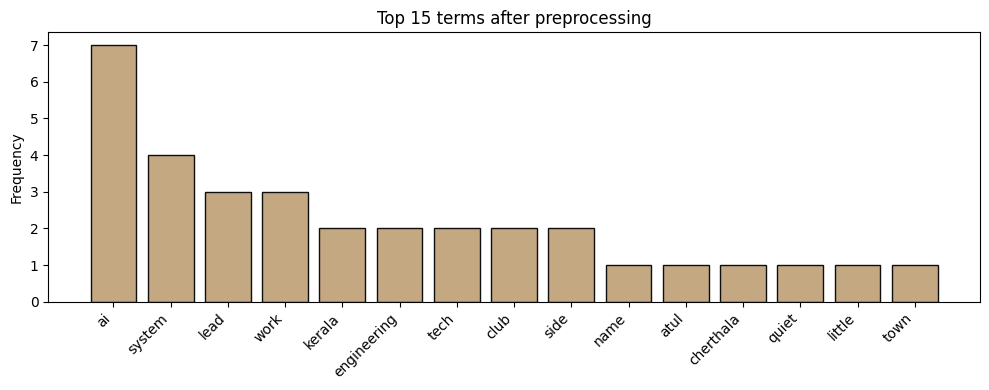

In [16]:
import matplotlib.pyplot as plt

top = fdist.most_common(15)
plt.figure(figsize=(10, 4))
plt.bar([w for w, _ in top], [c for _, c in top], color="#C4A882", edgecolor="#0E0E0E")
plt.xticks(rotation=45, ha="right")
plt.title("Top 15 terms after preprocessing")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 16. N-grams

In [17]:
bigrams  = list(ngrams(tokens_lemmatized, 2))
trigrams = list(ngrams(tokens_lemmatized, 3))

print("Bigrams:", len(bigrams), "| Trigrams:", len(trigrams), "\n")
print("Top 10 bigrams:")
for g, c in FreqDist(bigrams).most_common(10):
    print(f"  {' '.join(g):<35} {c}")

print("\nTop 10 trigrams:")
for g, c in FreqDist(trigrams).most_common(10):
    print(f"  {' '.join(g):<45} {c}")

Bigrams: 157 | Trigrams: 156 

Top 10 bigrams:
  tech lead                           2
  ai club                             2
  lead ai                             2
  name atul                           1
  atul cherthala                      1
  cherthala quiet                     1
  quiet little                        1
  little town                         1
  town alappuzha                      1
  alappuzha district                  1

Top 10 trigrams:
  name atul cherthala                           1
  atul cherthala quiet                          1
  cherthala quiet little                        1
  quiet little town                             1
  little town alappuzha                         1
  town alappuzha district                       1
  alappuzha district kerala                     1
  district kerala india                         1
  kerala india school                           1
  india school kerala                           1


## 17. Vectorisation — Bag of Words and TF-IDF

Each **sentence** of the paragraph is treated as a document, so the corpus has as many documents as
sentences. This is what makes IDF meaningful.

In [18]:
def preprocess(doc):
    doc = remove_emoji(remove_emails(remove_urls(remove_html(doc))))
    doc = contractions.fix(doc).lower()
    doc = re.sub(r"\d+", " ", doc).translate(str.maketrans("", "", string.punctuation))
    toks = [t for t in word_tokenize(re.sub(r"\s+", " ", doc).strip())
            if t not in stop_words and len(t) > 1]
    return " ".join(lem.lemmatize(t, penn_to_wordnet(p)) for t, p in nltk.pos_tag(toks))

corpus = [preprocess(s) for s in sentences]
print("Documents in corpus:", len(corpus))
print("\nDocument 1 after full pipeline:\n", corpus[0])

Documents in corpus: 11

Document 1 after full pipeline:
 name atul cherthala quiet little town alappuzha district kerala india


In [19]:
cv = CountVectorizer()
bow = cv.fit_transform(corpus)
bow_df = pd.DataFrame(bow.toarray(), columns=cv.get_feature_names_out(),
                      index=[f"S{i+1}" for i in range(len(corpus))])

print("Bag-of-Words matrix shape:", bow.shape, "(documents x vocabulary)")
print("\nFirst 12 vocabulary columns:\n")
print(bow_df.iloc[:, :12].to_string())

Bag-of-Words matrix shape: (11, 140) (documents x vocabulary)

First 12 vocabulary columns:

     achievement  adi  adversarial  agent  agentic  ai  aidriven  alappuzha  appoint  artificial  atul  august
S1             0    0            0      0        0   0         0          1        0           0     1       0
S2             0    1            0      0        0   0         0          0        0           1     0       0
S3             0    0            0      0        0   0         0          0        0           0     0       0
S4             0    0            0      1        0   1         0          0        0           0     0       1
S5             0    0            0      0        0   2         1          0        0           0     0       0
S6             1    0            0      0        0   2         0          0        1           0     0       0
S7             0    0            0      0        0   0         0          0        0           0     0       0
S8             0   

In [20]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(corpus)
tfidf_df = pd.DataFrame(X.toarray(), columns=tfidf.get_feature_names_out(),
                        index=[f"S{i+1}" for i in range(len(corpus))])

print("TF-IDF matrix shape:", X.shape, "\n")
print("Highest-scoring term in each sentence (most distinctive word):\n")
for i, row in tfidf_df.iterrows():
    print(f"  {i}: {row.idxmax():<20} {row.max():.4f}")

TF-IDF matrix shape: (11, 140) 

Highest-scoring term in each sentence (most distinctive word):

  S1: alappuzha            0.3206
  S2: engineering          0.4393
  S3: australia            0.2425
  S4: agent                0.2432
  S5: lead                 0.4007
  S6: ai                   0.2991
  S7: challenge            0.2425
  S8: ai                   0.4195
  S9: debug                0.2941
  S10: need                 0.3280
  S11: code                 0.5774


## 18. Pipeline summary — verification of output

In [21]:
summary = pd.DataFrame([
    ["0. Raw text",              len(raw_text),        len(raw_text.split()),        len(set(raw_text.lower().split()))],
    ["1. Noise removed",         len(text_clean),      len(text_clean.split()),      len(set(text_clean.lower().split()))],
    ["2. Contractions expanded", len(text_expanded),   len(text_expanded.split()),   len(set(text_expanded.lower().split()))],
    ["3. Lowercased",            len(text_lower),      len(text_lower.split()),      len(set(text_lower.split()))],
    ["4. Digits removed",        len(text_nonum),      len(text_nonum.split()),      len(set(text_nonum.split()))],
    ["5. Punctuation + spaces",  len(text_norm),       len(text_norm.split()),       len(set(text_norm.split()))],
    ["6. Tokenised",             None,                 len(tokens),                  len(set(tokens))],
    ["7. Stopwords removed",     None,                 len(tokens_nostop),           len(set(tokens_nostop))],
    ["8. Stemmed (Porter)",      None,                 len(tokens_stemmed),          len(set(tokens_stemmed))],
    ["9. Lemmatised (POS-aware)",None,                 len(tokens_lemmatized),       len(set(tokens_lemmatized))],
], columns=["Stage", "Characters", "Tokens", "Unique tokens"])

print(summary.to_string(index=False))

print("\n" + "=" * 62)
print("FINAL PREPROCESSED OUTPUT")
print("=" * 62)
print(" ".join(tokens_lemmatized))
print("=" * 62)
print(f"\nCompression: {len(raw_text.split())} words -> {len(tokens_lemmatized)} tokens "
      f"({100 * (1 - len(tokens_lemmatized) / len(raw_text.split())):.1f}% reduction)")
print(f"Vocabulary:  {len(set(raw_text.lower().split()))} -> {len(set(tokens_lemmatized))} unique terms")

                    Stage  Characters  Tokens  Unique tokens
              0. Raw text      1835.0     291            202
         1. Noise removed      1771.0     289            199
 2. Contractions expanded      1780.0     295            198
            3. Lowercased      1780.0     295            198
        4. Digits removed      1770.0     290            194
  5. Punctuation + spaces      1674.0     280            182
             6. Tokenised         NaN     280            182
     7. Stopwords removed         NaN     158            143
      8. Stemmed (Porter)         NaN     158            139
9. Lemmatised (POS-aware)         NaN     158            140

FINAL PREPROCESSED OUTPUT
name atul cherthala quiet little town alappuzha district kerala india school kerala state syllabus currently finalyear btech student computer science engineering artificial intelligence adi shankara institute engineering technology graduate live malayalamspeaking household parent elder sister study de

## 19. Observations

1. **Ordering is not arbitrary.** Contractions must be expanded before punctuation is stripped, or
   `didn't` becomes the junk token `didnt`. URLs must be removed before punctuation, or one link
   explodes into a dozen fragments. NER must run before lowercasing, because capitalisation is one
   of the strongest entity features.
2. **Stemming vs lemmatisation.** Lancaster over-stems aggressively and destroys readability;
   Porter is conservative but still produces non-words. POS-aware lemmatisation returns real
   dictionary forms and is the right default when the output must remain human-readable.
3. **Naive lemmatisation is a silent failure.** `WordNetLemmatizer` defaults to noun, so verbs pass
   through unchanged and the bug never raises an error — it just quietly degrades the vocabulary.
4. **Stopword lists need editing.** The default NLTK list removes `not`, `no` and `nor`, which
   inverts meaning. They were explicitly retained here.
5. **Net effect.** The pipeline reduced the paragraph substantially in token count while increasing
   information density — every surviving token is a content-bearing term suitable for downstream
   vectorisation.